In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.data_processing.splitting import split_data
from src.data_processing.esc50_dataset import ESC50Dataset
#from src.models.CNN_model import AudioCNN, DeepAudioCNN
from src.models.mobilenet_model import AudioMobileNetV2

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Обучение на устройство: {device}")

# НОВИТЕ ПЪТИЩА КЪМ СЕГМЕНТИРАНИТЕ ДАННИ!
CSV_PATH = "../data/processed/esc50_segmented.csv"
AUDIO_DIR = "../data/processed/segmented_audio/"
MODEL_SAVE_PATH = "../models/mobilenet_model.pth"

os.makedirs("../models", exist_ok=True)

Обучение на устройство: cpu


In [2]:
# Разделяне на метаданните (Фолдовете си остават същите, така че няма Data Leakage!)
train_df, val_df, test_df = split_data(CSV_PATH)

print("Създаване на Dataset обекти...")
train_dataset = ESC50Dataset(train_df, AUDIO_DIR)
encoder = train_dataset.label_encoder 

val_dataset = ESC50Dataset(val_df, AUDIO_DIR, label_encoder=encoder)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


Създаване на Dataset обекти...


In [3]:
model = AudioMobileNetV2(n_classes=50).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler: намалява стъпката наполовина, ако няма подобрение 5 епохи
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

EPOCHS = 100
best_val_loss = float('inf')
patience = 15 # Спираме след 15 епохи без подобрение
patience_counter = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

In [4]:
for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    current_lr = optimizer.param_groups[0]['lr']
    
    for inputs, labels in tqdm(train_loader, desc=f"Епоха {epoch+1}/{EPOCHS} [LR: {current_lr:.6f}]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    
    # --- VALIDATION ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    
    # Запазване в историята
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # --- УМНИ ПРОВЕРКИ ---
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"🌟 Нов най-добър модел е запазен! (Val Loss: {best_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️ Няма подобрение от {patience_counter} епохи.")
        
    print("-" * 60)
    
    if patience_counter >= patience:
        print(f"🛑 Ранно спиране активирано на епоха {epoch+1}!")
        break

print("🎉 Обучението приключи!")

Епоха 1/100 [LR: 0.001000]:   0%|          | 0/108 [00:00<?, ?it/s]C:\Users\FHPopova21\source\repos\Ambient-Sound-Awareness-System-ASAS-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Епоха 1/100 [LR: 0.001000]: 100%|██████████| 108/108 [00:59<00:00,  1.81it/s]


Train Loss: 1.9124 | Train Acc: 50.15% || Val Loss: 1.2998 | Val Acc: 61.68%
🌟 Нов най-добър модел е запазен! (Val Loss: 1.2998)
------------------------------------------------------------


Епоха 2/100 [LR: 0.001000]: 100%|██████████| 108/108 [00:47<00:00,  2.27it/s]


Train Loss: 0.7049 | Train Acc: 79.44% || Val Loss: 1.3556 | Val Acc: 63.78%
⚠️ Няма подобрение от 1 епохи.
------------------------------------------------------------


Епоха 3/100 [LR: 0.001000]: 100%|██████████| 108/108 [00:48<00:00,  2.24it/s]


...

Train Loss: 0.0028 | Train Acc: 99.91% || Val Loss: 1.0204 | Val Acc: 79.08%
⚠️ Няма подобрение от 13 епохи.
------------------------------------------------------------


Епоха 37/100 [LR: 0.000125]: 100%|██████████| 108/108 [00:49<00:00,  2.16it/s]


Train Loss: 0.0014 | Train Acc: 99.97% || Val Loss: 0.9844 | Val Acc: 79.24%
⚠️ Няма подобрение от 14 епохи.
------------------------------------------------------------


Епоха 38/100 [LR: 0.000125]: 100%|██████████| 108/108 [00:50<00:00,  2.15it/s]


Train Loss: 0.0022 | Train Acc: 99.97% || Val Loss: 1.0037 | Val Acc: 78.82%
⚠️ Няма подобрение от 15 епохи.
------------------------------------------------------------
🛑 Ранно спиране активирано на епоха 38!
🎉 Обучението приключи!


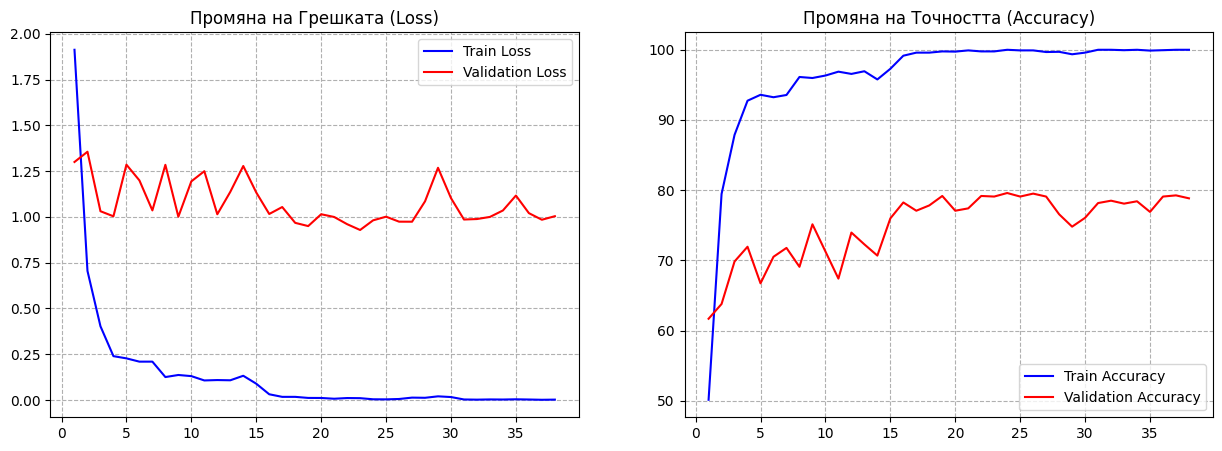

In [5]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss', color='red')
axes[0].set_title('Промяна на Грешката (Loss)')
axes[0].legend()
axes[0].grid(True, linestyle='--')

axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(epochs_range, history['val_acc'], label='Validation Accuracy', color='red')
axes[1].set_title('Промяна на Точността (Accuracy)')
axes[1].legend()
axes[1].grid(True, linestyle='--')

plt.show()